### Plot snapshots of surface vorticity, numerical mixing, and physical mixing
Horizontal resolutions used: 100 m, 500 m, 1km, 2km, 5km, and 10km

In [1]:
#Packages 
import numpy as np
import xarray as xr
import glob
import cmocean.cm as cmo
import matplotlib.cm as cmx
import matplotlib.pyplot as plt
import matplotlib.ticker as tick
import warnings
warnings.filterwarnings("ignore") #turns off annoying warnings
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import FuncFormatter
import mosaic
from matplotlib.colors import SymLogNorm
from matplotlib.colors import LinearSegmentedColormap
import os
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable

### Interpolate physical mixing and center vertices for plotting 

In [2]:
def interp_mphy(ds):
    # Interpolate only the top 2 levels of chiPhyVerSalt. This greatly 
    # speeds up processing time for the 100 m case and avoids OOM errors
    mphys_interp_top2 = 0.5 * (
        ds.chiPhyVerSalt.isel(nVertLevelsP1=slice(0, 2)) +  # levels 0–1
        ds.chiPhyVerSalt.isel(nVertLevelsP1=slice(1, 3))    # levels 1–2
    )
    mphys_interp_top2 = mphys_interp_top2.rename({'nVertLevelsP1': 'nVertLevels'})
    
    # Assign only top 2 nVertLevels coordinates
    mphys_interp_top2 = mphys_interp_top2.assign_coords(
        nVertLevels=ds.nVertLevels.isel(nVertLevels=slice(0, 2))
    )

    # Create a copy of the original variable (with all levels)
    full_salt = ds.chiPhyVerSalt
    # Drop the top nVertLevelsP1 level to get nVertLevels (standard practice)
    full_salt_interp = full_salt.isel(nVertLevelsP1=slice(1, None))
    full_salt_interp = full_salt_interp.rename({'nVertLevelsP1': 'nVertLevels'})
    full_salt_interp = full_salt_interp.assign_coords(nVertLevels=ds.nVertLevels)

    # Replace top 2 levels with interpolated values
    full_salt_interp = full_salt_interp.copy()
    full_salt_interp[{ 'nVertLevels': slice(0, 2) }] = mphys_interp_top2

    # Update dataset
    ds['chiPhyVerSalt'] = full_salt_interp

    return ds

def center_vertices(dsg, hres):
    # Clean up the indexing so the domain is centered for plotting

    # Original vertices (x,y) arrays
    xv = dsg.xVertex.values
    yv = dsg.yVertex.values
    
    # Compute the new vertices based on your filtering and offset logic:
    
    # 1. Extract verticesOnCell (assuming shape: [nCells, maxVerticesPerCell])
    voc = dsg.verticesOnCell.values
    
    # 2. Build verts as in your snippet (shape: [nCells, maxVerticesPerCell, 2])
    verts = np.dstack((xv[voc - 1], yv[voc - 1]))
    nverts = np.sum(voc != 0, axis=1)
    verts_list = [vert[:n] for vert, n in zip(verts, nverts)]
    
    # 3. Filter verts using np.ptp
    idx = [np.ptp(vert[:, 0]) < 50000 for vert in verts_list]
    verts_filtered = np.array(verts_list)[idx]
    
    # 4. Copy and apply offsets
    nuverts = verts_filtered.copy()
    m_dsx = hres
    nuverts[:, :, 0] += m_dsx / 2
    nuverts[:, :, 1] -= m_dsx
    
    # Now, update dsg's xVertex and yVertex arrays accordingly:
    # But note: verts are grouped by cell, so we need to flatten and assign properly.
    
    # Because verts_filtered is a filtered subset of verts_list,
    # you should update only those cells where idx is True.
    
    # Get indices of cells that passed filter
    filtered_cells = np.where(idx)[0]
    
    # Create copies of xVertex and yVertex to modify
    new_xVertex = xv.copy()
    new_yVertex = yv.copy()
    
    # Loop over filtered cells and update the corresponding vertex coords
    for cell_i, verts_cell in zip(filtered_cells, nuverts):
        nv = verts_cell.shape[0]  # number of vertices for this cell
        vertex_inds = voc[cell_i, :nv] - 1  # zero-based vertex indices for this cell
        new_xVertex[vertex_inds] = verts_cell[:, 0]
        new_yVertex[vertex_inds] = verts_cell[:, 1]
    
    # Assign back to dsg (if dsg is an xarray Dataset or DataArray)
    dsg['xVertex'].values = new_xVertex
    dsg['yVertex'].values = new_yVertex

### Open output and apply functions, but only at a single timestep to reduce computational time for the 100 m simulation

In [3]:
# === Configuration ===
resolutions = [10000, 5000, 2000, 1000, 500]  # 100m handled separately
layers = [50, 100]
snapshot_time = b"0001-01-17_04:00:00"  # Time to select

# Base path template
base_path_template = '/pscratch/sd/d/dylan617/bichan/mpaso/new_hres/{res_km}/'

# Special case: 100m output paths
path_100m_output = '/global/cfs/projectdirs/m4572/dylan617/bichan/100m/output_100m_50_layers_days_1_16.nc'
path_100m_dvd = '/global/cfs/projectdirs/m4572/dylan617/bichan/100m/analysis_members/discreteVarianceDecay_100m_50_layers_days_1_16.0001-01-01.nc'

# Store datasets in nested dictionaries
datasets = {}

# Process standard resolutions
for res in resolutions:
    res_km = res / 1000
    if res_km >= 1.0:
        res_dir = f'{int(res_km)}km'
        res_key = f'{int(res_km)}km'
    else:
        res_dir = f'{res}m'
        res_key = f'{res}m'

    datasets[res_key] = {}
    rootdir = base_path_template.format(res_km=res_dir)

    for layer in layers:
        key = f'z{layer}'

        output_file = f'{rootdir}output_{res}m_{layer}_layers.nc'
        init_file = f'{rootdir}channel_{res}m_{layer}_layers_init.nc'
        decay_file = f'{rootdir}analysis_members/discreteVarianceDecay_{res}m_{layer}_layers.0001-01-01.nc'

        if not all(os.path.exists(f) for f in [output_file, init_file, decay_file]):
            print(f"Skipping resolution {res_key}, layer {layer} due to missing files.")
            continue

        # Open and select only the specified time
        dso = xr.open_dataset(output_file)
        dso['Time'] = dso.xtime
        if snapshot_time not in dso.Time.values:
            print(f"Time {snapshot_time} not found in {output_file}")
            continue
        dso = dso.sel(Time=snapshot_time)

        dsd = xr.open_dataset(decay_file)
        dsd['Time'] = dsd.xtime
        if snapshot_time not in dsd.Time.values:
            print(f"Time {snapshot_time} not found in {decay_file}")
            continue
        dsd = dsd.sel(Time=snapshot_time)

        dsg = xr.open_dataset(init_file)

        datasets[res_key][key] = {
            'output': dso,
            'init': dsg,
            'decay': dsd
        }

# Special case: 100m resolution with only z50 layer
res_key = '100m'
key = 'z50'
res_dir = '100m'
rootdir = base_path_template.format(res_km=res_dir)
init_file_100m = f'{rootdir}channel_100m_50_layers_init.nc'

if all(os.path.exists(f) for f in [path_100m_output, path_100m_dvd, init_file_100m]):
    dso = xr.open_dataset(path_100m_output)
    dso['Time'] = dso.xtime
    if snapshot_time not in dso.Time.values:
        print(f"Time {snapshot_time} not found in {path_100m_output}")
    else:
        dso = dso.sel(Time=snapshot_time)

        dsd = xr.open_dataset(path_100m_dvd)
        dsd['Time'] = dsd.xtime
        if snapshot_time not in dsd.Time.values:
            print(f"Time {snapshot_time} not found in {path_100m_dvd}")
        else:
            dsd = dsd.sel(Time=snapshot_time)
            dsg = xr.open_dataset(init_file_100m)

            datasets[res_key] = {
                key: {
                    'output': dso,
                    'init': dsg,
                    'decay': dsd
                }
            }
else:
    print("Skipping 100m z50 due to missing files.")


Skipping 100m z50 due to missing files.


In [4]:
# Mapping from '10km' to resolution in meters
res_km_to_dx = {
    '10km': 10000,
    '5km': 5000,
    '2km': 2000,
    '1km': 1000,
    '500m': 500, 
    '100m': 100
}

# Loop over all datasets and apply functions
for res_key, layers_dict in datasets.items():
    dx = res_km_to_dx[res_key]  # Horizontal resolution in meters
    print(dx)

    for layer_key, files in layers_dict.items():
        decay_ds = files['decay']
        init_ds = files['init']

        # Apply functions
        interp_mphy(decay_ds)
        center_vertices(init_ds, dx)


10000
5000
2000
1000
500
100


### Pre-plotting for mosaic and colorbar tweaks

In [5]:
# Create a descriptor dictionary dynamically
descriptors = {}

for res_key, layers_dict in datasets.items():
    # Grab one of the 'init' datasets to build the descriptor
    # We'll use the first available layer
    if not layers_dict:
        continue

    first_layer = next(iter(layers_dict.values()))
    init_ds = first_layer['init']
    
    # Create and store descriptor
    descriptors[res_key] = mosaic.Descriptor(init_ds, use_latlon=False)


# Used for plotting mnum on a diverging log colorbar
# Otherwise the extrema look the same for most cmocean maps. That is, 
# you can't tell dark reds or blues apart. 
def truncate_colormap(cmap, minval=0.0, maxval=0.8, n=256):
    """Truncates a colormap to use only part of the range."""
    new_cmap = LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

curl = truncate_colormap(plt.get_cmap('cmo.curl'), 0.15, 0.85)

# Helper to safely compute log10 for plotting, otherwise it is masked for 
# very small values
def safe_log10(data, floor=1e-50):
    """Compute log10 of xarray DataArray safely, keeping dimensions and attrs."""
    # Replace nonpositive or nonfinite values with floor
    data_clean = data.where((data > 0) & np.isfinite(data), other=floor)
    return np.log10(data_clean)

### Plot vorticity, numerical mixing, and physical mixing

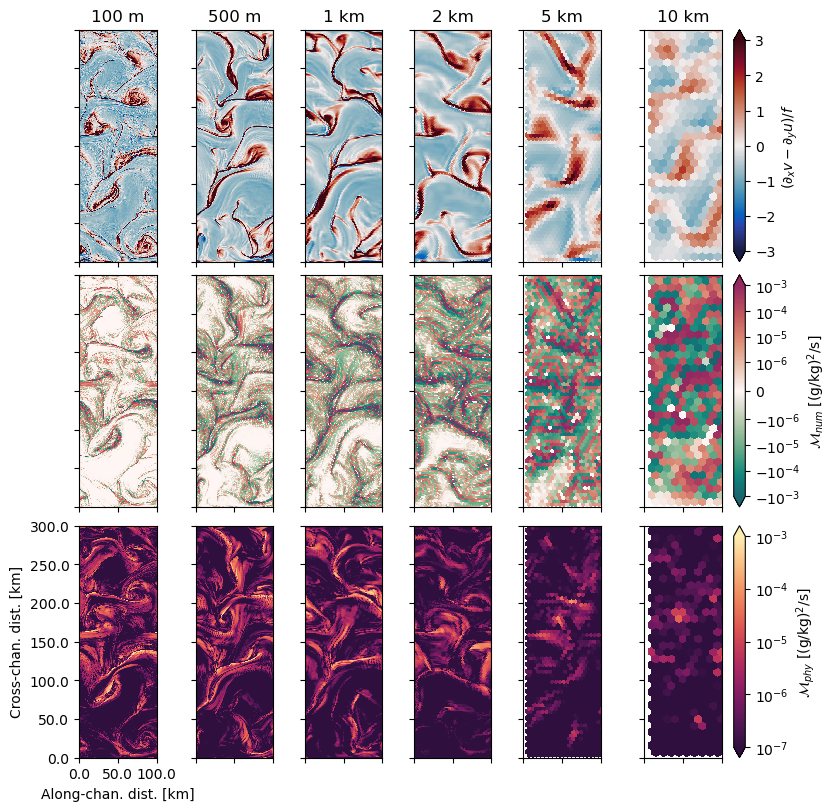

In [21]:
# === Configuration ===
layer_key = 'z50'
res_keys = ['100m', '500m', '1km', '2km', '5km', '10km']
titles = ['100 m', '500 m', '1 km', '2 km', '5 km', '10 km']
z = 0
absmax = 1e-3
linthresh = 1e-6

# === Figure and Axes ===
fig, ax = plt.subplots(nrows=3, ncols=6, figsize=(8.25, 8), constrained_layout=True)

# === Plotting Rows ===
for i in range(3):
    c = None  # To keep last mappable for colorbar
    for j, res_key in enumerate(res_keys):
        a = ax[i, j]
        files = datasets[res_key][layer_key]
        descriptor = descriptors[res_key]

        if i == 0:
            dso = files['output']
            grid = files['init']
            data = dso.relativeVorticityCell.isel(nVertLevels=z) / grid.fCell
            c = mosaic.polypcolor(a, descriptor, data, cmap=cmo.balance, vmin=-3, vmax=3, antialiaseds=False)

        elif i == 1:
            decay = files['decay']
            data = decay.chiSpurSaltBR08.isel(nVertLevels=z)
            norm = SymLogNorm(linthresh=linthresh, vmin=-absmax, vmax=absmax)
            c = mosaic.polypcolor(a, descriptor, data, cmap=curl, norm=norm, antialiaseds=False)

        elif i == 2:
            decay = files['decay']
            data = safe_log10(decay.chiPhyVerSalt.sel(nVertLevels=z))
            c = mosaic.polypcolor(a, descriptor, data, cmap=cmo.matter_r, vmin=-7, vmax=-3, antialiaseds=False)

        # Titles only for top row
        if i == 0:
            a.set_title(titles[j])

    # Add colorbar for the last subplot in this row
    if i == 0:
        cbar_label = r'$(\partial_x v - \partial_y u)/f$'
        fig.colorbar(c, ax=ax[i, -1],
                     label=cbar_label, extend='both',pad=0.12)
    elif i == 1:
        cbar_label = r'$\mathcal{M}_{num}$ [(g/kg)$^2$/s]'
        fig.colorbar(c, ax=ax[i, -1],
                     label=cbar_label, extend='both',pad=0.12)
    else:  # i == 2
        cbar_label = r'$\mathcal{M}_{phy}$ [(g/kg)$^2$/s]'
        fig.colorbar(c, ax=ax[i, -1],
                     label=cbar_label, extend='both',
                     format=tick.FormatStrFormatter('$10^{%d}$'),pad=0.12)

# === Format Axes ===
for i in range(3):
    for j in range(6):
        a = ax[i, j]
        a.set_xticks(np.arange(0, 350000, 50000))
        a.set_yticks(np.arange(0, 350000, 50000))
        a.set_xlim(0, 100000)
        a.set_ylim(0, 300000)
        a.set_aspect(1.0)
        a.set_xticklabels([str(x / 1000.0) for x in a.get_xticks()])
        a.set_yticklabels([str(y / 1000.0) for y in a.get_yticks()])
        a.set_xlabel('')
        a.set_ylabel('')

# === Hide all ticks except bottom-left ===
for i in range(3):
    for j in range(6):
        if not (i == 2 and j == 0):
            ax[i, j].set_xticklabels([])
            ax[i, j].set_yticklabels([])

# === Final axis labels ===
ax[2, 0].set_xlabel('Along-chan. dist. [km]')
ax[2, 0].set_ylabel('Cross-chan. dist. [km]')


for j in range(1, 6):  # Only first column shows y-ticks in last row
    ax[2, j].set_yticklabels([])

# === Final axis labels ===
ax[2, 0].set_xlabel('Along-chan. dist. [km]')
ax[2, 0].set_ylabel('Cross-chan. dist. [km]')

# === Show or save ===
fig.canvas.draw()
plt.savefig('plan_view_hres.png', dpi=500)
# plt.show()


Note: Process offline in powerpoint or keynote to remove awkward spacing in the last column 